# Preparation


In [1]:
# Optional packages, if the environment does not already include them:
# %pip install geopandas country_converter

from collections import Counter
from itertools import combinations
from matplotlib.collections import LineCollection
from pathlib import Path
from networkx.algorithms import community
import itertools
import re

import country_converter as coco
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

PROJECT_DIR = Path(r"D:\master\M2\History\Myfinal\data")
EXCLUDED_YEAR = 2026
DROPPED_COLUMNS = ["citing_eids", "citing_titles", "citing_count_from_search"]


def read_paper_dataset(filename):
    df = pd.read_csv(PROJECT_DIR / filename, encoding="utf-8-sig")
    df = df.drop_duplicates(subset=["title"], keep="first").reset_index(drop=True)
    df = df[df["year"] != EXCLUDED_YEAR].reset_index(drop=True)
    return df.drop(columns=DROPPED_COLUMNS, errors="ignore")


def read_author_dataset(filename):
    df = pd.read_csv(PROJECT_DIR / filename, encoding="utf-8-sig")
    df = df.drop_duplicates(
        subset=["title", "parsed_author_name"],
        keep="first",
    ).reset_index(drop=True)
    return df[df["year"] != EXCLUDED_YEAR].reset_index(drop=True)


def save_figure(filename, **kwargs):
    plt.savefig(PROJECT_DIR / filename, **kwargs)


The main sample is restricted to publications classified in Scopus under Economics, Econometrics, and Finance (`SUBJAREA: ECON`). As a robustness check, the analysis also considers broader samples that add adjacent social science fields (`SOCI`, `BUSI`, `PSYC`).


In [2]:
# Main dataset
df_main = read_paper_dataset("gender_gap_econ_strict_paper.csv")
print(df_main.head())
print(df_main.columns.tolist())
print(f"Number of rows in df_main: {len(df_main)}")

df_main_long = read_author_dataset("gender_gap_econ_strict_author_long.csv")
print(df_main_long.head())
print(df_main_long.columns.tolist())
print(f"Number of rows in df_main_long: {len(df_main_long)}")


                   eid                                              title  \
0  2-s2.0-105024594606  Impacts of women's political and economic empo...   
1   2-s2.0-85217390477  Moving up the social ladder? Wages of first- a...   
2   2-s2.0-85217360336  The gender pay gap at the early stages of acad...   
3   2-s2.0-85213213070  Enforcing ‘Equal Pay for Equal Work’ in the EU...   
4   2-s2.0-85183759833   Gender wage gap and male perpetrated child abuse   

                                             authors  \
0           Zhu, Ning;Gaweł, Aleksandra;Toikko, Timo   
1  Pineda-Hernández, Kevin;Rycx, François;Volral,...   
2  Magda, Iga;Bieliński, Jacek;Feldy, Marzena;Kna...   
3                       De Poli, Silvia;Maier, Sofia   
4                    Hans, Zainab;Belzer, Michael H.   

                                        author_ids  \
0               57221331701;56365732900;6507375063   
1               57226492706;6507107303;32668127500   
2  39961872000;57195933687;57215421464

In [3]:
# Check whether any paper is missing author information.
print(df_main[df_main["authors"].isna()])


                     eid                                              title  \
194  2-s2.0-105006888624  Comments by Riatu Mariatul Qibthiyyah, on The ...   
195  2-s2.0-105006887362  Comments by Soohyung Lee, on The Gender Wage G...   
680   2-s2.0-85190615854  Report from the Commission on the implementati...   
836   2-s2.0-85045019319             How to narrow Britain’s gender-pay gap   
837   2-s2.0-85044988733  Forcing employers to reveal their gender pay g...   
875   2-s2.0-85031678105            Men, women and work: The gender pay gap   

    authors author_ids author_afids  year  cover_date  \
194     NaN        NaN          NaN  2024  2024-10-01   
195     NaN        NaN          NaN  2024  2024-10-01   
680     NaN        NaN          NaN  2020  2020-01-01   
836     NaN        NaN          NaN  2018  2018-04-07   
837     NaN        NaN          NaN  2018  2018-04-07   
875     NaN        NaN          NaN  2017  2017-10-07   

                                      publicat

In [4]:
# Robustness-check datasets
df_plus = read_paper_dataset("gender_gap_econ_plus_paper.csv")
print(f"Number of rows in df_plus: {len(df_plus)}")

df_plus_long = read_author_dataset("gender_gap_econ_plus_author_long.csv")
print(f"Number of rows in df_plus_long: {len(df_plus_long)}")

df_all = read_paper_dataset("gender_gap_social_sciences_all_paper.csv")
print(f"Number of rows in df_all: {len(df_all)}")

df_all_long = read_author_dataset("gender_gap_social_sciences_all_author_long.csv")
print(f"Number of rows in df_all_long: {len(df_all_long)}")


Number of rows in df_plus: 3240
Number of rows in df_plus_long: 7176
Number of rows in df_all: 3255
Number of rows in df_all_long: 7209


# 0. Overview

Summary statistics for the main and robustness-check datasets.


In [ ]:
# Detailed summary of the main dataset

# =========================
# 1. CONFIGURE THE FILES
# =========================
main_file = {
    "Main (Economics only)": df_main,
}

# =========================
# 2. CONFIGURE COLUMN NAMES
# =========================
YEAR_COL = "year"
CITATION_COL = "citedby_count"
SOURCE_COL = "publication_name"
AUTHORS_COL = "authors"
AUTHOR_IDS_COL = "author_ids"


# =========================
# 3. HELPER FUNCTION
# =========================
# clean author names for better counting
def clean_author(name):
    name = str(name).strip()
    name = re.sub(r"\s+", " ", name)
    return name

def parse_author_pairs(authors_str, author_ids_str):
    if pd.isna(authors_str) or pd.isna(author_ids_str):
        return []

    authors = [clean_author(a) for a in str(authors_str).split(";")]
    author_ids = [str(aid).strip() for aid in str(author_ids_str).split(";")]

    # remove empty values
    authors = [a for a in authors if a != ""]
    author_ids = [aid for aid in author_ids if aid != ""]

    # ensure the lengths match
    n = min(len(authors), len(author_ids))

    return list(zip(author_ids[:n], authors[:n]))

# for _, row in df_main[["authors", "author_ids"]].dropna().head(5).iterrows():
#     print(parse_author_pairs(row["authors"], row["author_ids"]))

def detailed_summarize_dataset(file):
    df = pd.DataFrame(file)

    # Drop rows with all empty values
    df = df.dropna(how="all").copy()

    # -------- Total Publications(TP) --------
    documents = len(df)

    # -------- Sources (Journals) --------
    if SOURCE_COL in df.columns:
        sources = df[SOURCE_COL].dropna().astype(str).str.strip()
        n_sources = sources[sources != ""].nunique()
    else:
        n_sources = np.nan

    # -------- Number of Contributing Authors (NCA) --------
    # Counts unique author names across all documents
    if AUTHOR_IDS_COL in df.columns:
        author_set = set()

        for value in df[AUTHOR_IDS_COL].dropna():
            author_ids = str(value).split(";")
            author_ids = [aid.strip() for aid in author_ids if aid.strip()]
            author_set.update(author_ids)

        n_authors = len(author_set)
    else:
        n_authors = np.nan

    # -------- Sole-authored publications (SA) & Co-authored publications (CA) --------
    if AUTHOR_IDS_COL in df.columns:
        sap = 0
        cap = 0
        for value in df[AUTHOR_IDS_COL].dropna():
            author_ids = str(value).split(";")
            author_ids = [aid.strip() for aid in author_ids if aid.strip()]
            if len(author_ids) == 1:
                sap += 1
            else:
                cap += 1
    else:
        sap = np.nan
        cap = np.nan

    # -------- Period --------
    if YEAR_COL in df.columns:
        years = pd.to_numeric(df[YEAR_COL], errors="coerce").dropna()
        if len(years) > 0:
            period = f"{int(years.min())}-{int(years.max())}"
        else:
            period = np.nan
    else:
        period = np.nan

    #-------- Productivity per active years of publication(PAY) --------
    if YEAR_COL in df.columns:
        years = pd.to_numeric(df[YEAR_COL], errors="coerce").dropna()
        active_years = years.max() - years.min() + 1 if len(years) > 0 else np.nan
        productivity = round(documents / active_years, 2) if pd.notna(active_years) and active_years > 0 else np.nan
    else:
        productivity = np.nan

    #-------- Total Citations (TC) --------
    if CITATION_COL in df.columns:
        citations = pd.to_numeric(df[CITATION_COL], errors="coerce")
        total_citations = citations.sum(skipna=True)
    else:
        total_citations = np.nan

    # -------- Average citations (AC)--------
    if CITATION_COL in df.columns:
        citations = pd.to_numeric(df[CITATION_COL], errors="coerce")
        avg_citations = citations.mean(skipna=True)
        avg_citations = round(avg_citations, 2) if pd.notna(avg_citations) else np.nan
    else:
        avg_citations = np.nan


    return {
        "Total Publications": documents,
        "Sources (Journals)": n_sources,
        "Period": period,
        "Sole-authored publications": sap,
        "Co-authored publications": cap,
        "Productivity per active years of publication": f"{productivity:.2f}",
        "Authors": n_authors,
        "Total citations": total_citations,
        "Average citations per document": f"{avg_citations:.2f}",
    }

# =========================
# 4. BUILD SUMMARY TABLE
# =========================
summary = {}

for category, file in main_file.items():
    summary[category] = detailed_summarize_dataset(file)

summary_df = pd.DataFrame(summary)
summary_df.index.name = "Description"

latex_table = summary_df.to_latex()
print(latex_table)


\begin{tabular}{ll}
\toprule
 & Main (Economics only) \\
Description &  \\
\midrule
Total Publications & 1638 \\
Sources (Journals) & 423 \\
Period & 1987-2025 \\
Sole-authored publications & 451 \\
Co-authored publications & 1181 \\
Productivity per active years of publication & 42.00 \\
Authors & 2821 \\
Total citations & 43412 \\
Average citations per document & 26.50 \\
\bottomrule
\end{tabular}



In [6]:
# Summary of all datasets

# =========================
# 1. CONFIGURE THE FILES
# =========================
files = {
    "Main (Economics only)": df_main,
    "Main + related social sciences": df_plus,
    "Main + all social sciences": df_all,
}

# =========================
# 2. CONFIGURE COLUMN NAMES
# =========================
YEAR_COL = "year"
CITATION_COL = "citedby_count"
SOURCE_COL = "publication_name"
AUTHORS_COL = "authors"
AUTHOR_SEPARATOR = ";"


# =========================
# 4. BUILD SUMMARY TABLE
# =========================
summary = {}

for category, file in files.items():
    summary[category] = detailed_summarize_dataset(file)

summary_df = pd.DataFrame(summary)
summary_df.index.name = "Description"

latex_table = summary_df.to_latex()
print(latex_table)


\begin{tabular}{llll}
\toprule
 & Main (Economics only) & Main + related social sciences & Main + all social sciences \\
Description &  &  &  \\
\midrule
Total Publications & 1638 & 3240 & 3255 \\
Sources (Journals) & 423 & 1057 & 1071 \\
Period & 1987-2025 & 1987-2025 & 1987-2025 \\
Sole-authored publications & 451 & 911 & 916 \\
Co-authored publications & 1181 & 2319 & 2329 \\
Productivity per active years of publication & 42.00 & 83.08 & 83.46 \\
Authors & 2821 & 5617 & 5644 \\
Total citations & 43412 & 78543 & 78601 \\
Average citations per document & 26.50 & 24.24 & 24.15 \\
\bottomrule
\end{tabular}



# 1. Performance Analysis

Publication, citation, author, institution, country, and journal indicators.


## 1.1 Publications by Year


The name of the first paper: Productivity and the role of college in narrowing the male.female wage differential in the USA in 1980


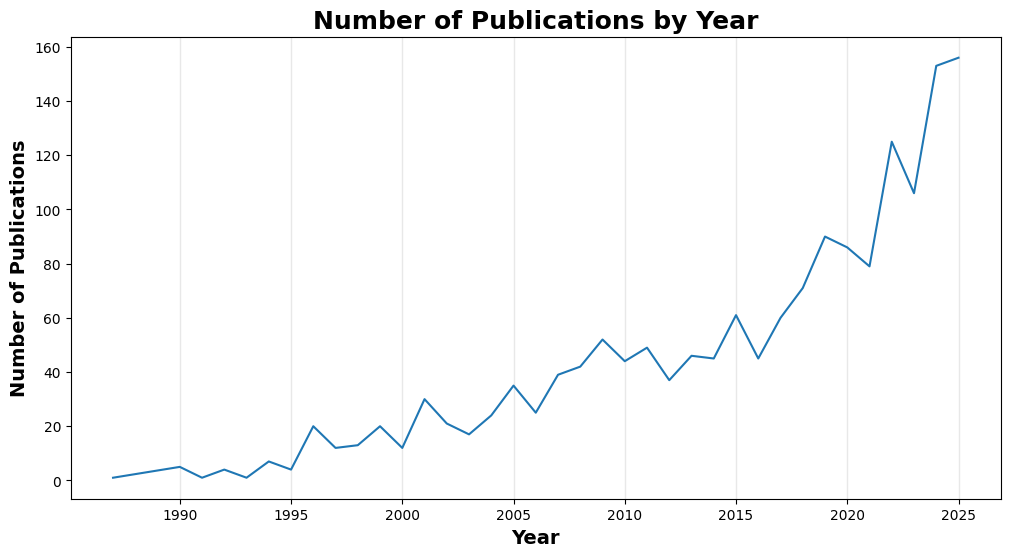

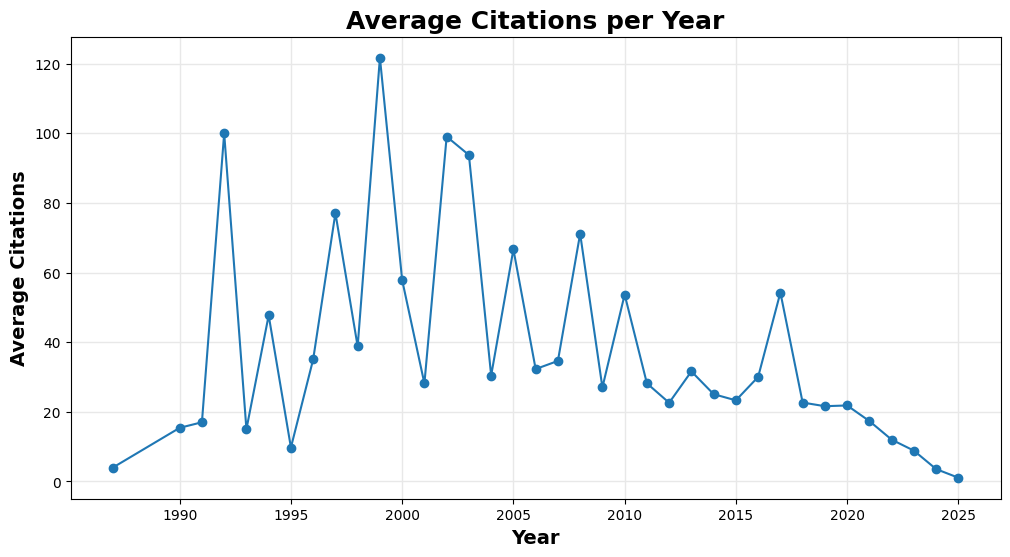

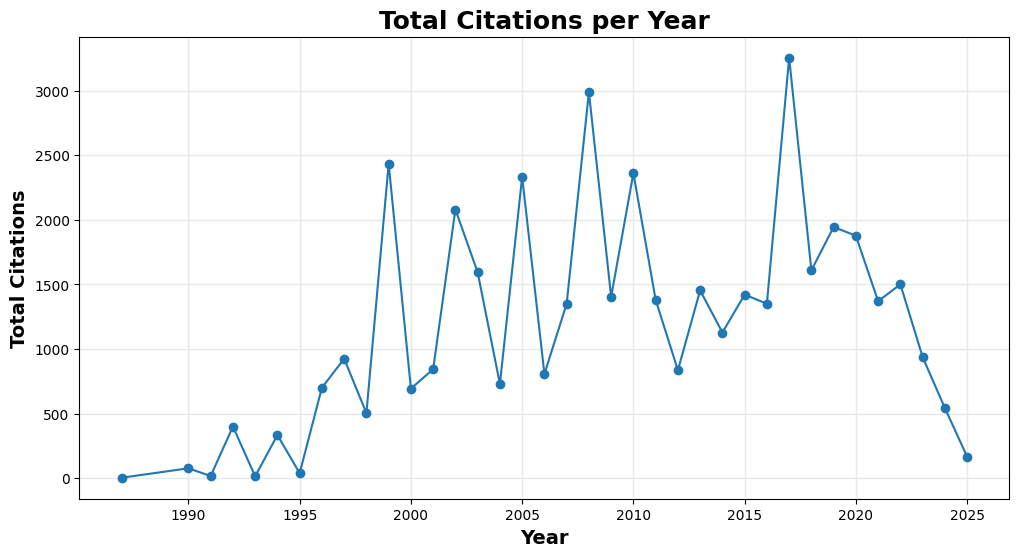

In [7]:
year_counts = df_main["year"].value_counts().sort_index()

# print(year_counts)

first_paper_name = df_main["title"][df_main["year"] == 1987].iloc[0]
print(f"The name of the first paper: {first_paper_name}")


fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(year_counts.index, year_counts.values)
ax.grid(True, which="major", color="#e8e8e8", linewidth=1)
ax.set_xlabel("Year", fontsize=14, fontweight="bold")
ax.set_ylabel("Number of Publications", fontsize=14, fontweight="bold")
ax.set_title("Number of Publications by Year", fontsize=18, fontweight="bold")
ax.grid(axis="y")

save_figure("publications_by_year.png", dpi=300)
plt.show()

df_main.groupby("year")["citedby_count"].mean().plot(kind="line", figsize=(12, 6), marker="o")
plt.title("Average Citations per Year", fontsize=18, fontweight="bold")
plt.xlabel("Year", fontsize=14, fontweight="bold")
plt.ylabel("Average Citations", fontsize=14, fontweight="bold")
plt.grid(True, which="major", color="#e8e8e8", linewidth=1)
save_figure("average_citations_by_year.png", dpi=300)
plt.show()

df_main.groupby("year")["citedby_count"].sum().plot(kind="line", figsize=(12, 6), marker="o")
plt.title("Total Citations per Year", fontsize=18, fontweight="bold")
plt.xlabel("Year", fontsize=14, fontweight="bold")
plt.ylabel("Total Citations", fontsize=14, fontweight="bold")
plt.grid(True, which="major", color="#e8e8e8", linewidth=1)
save_figure("total_citations_by_year.png", dpi=300)
plt.show()


## 1.2 Top Journals


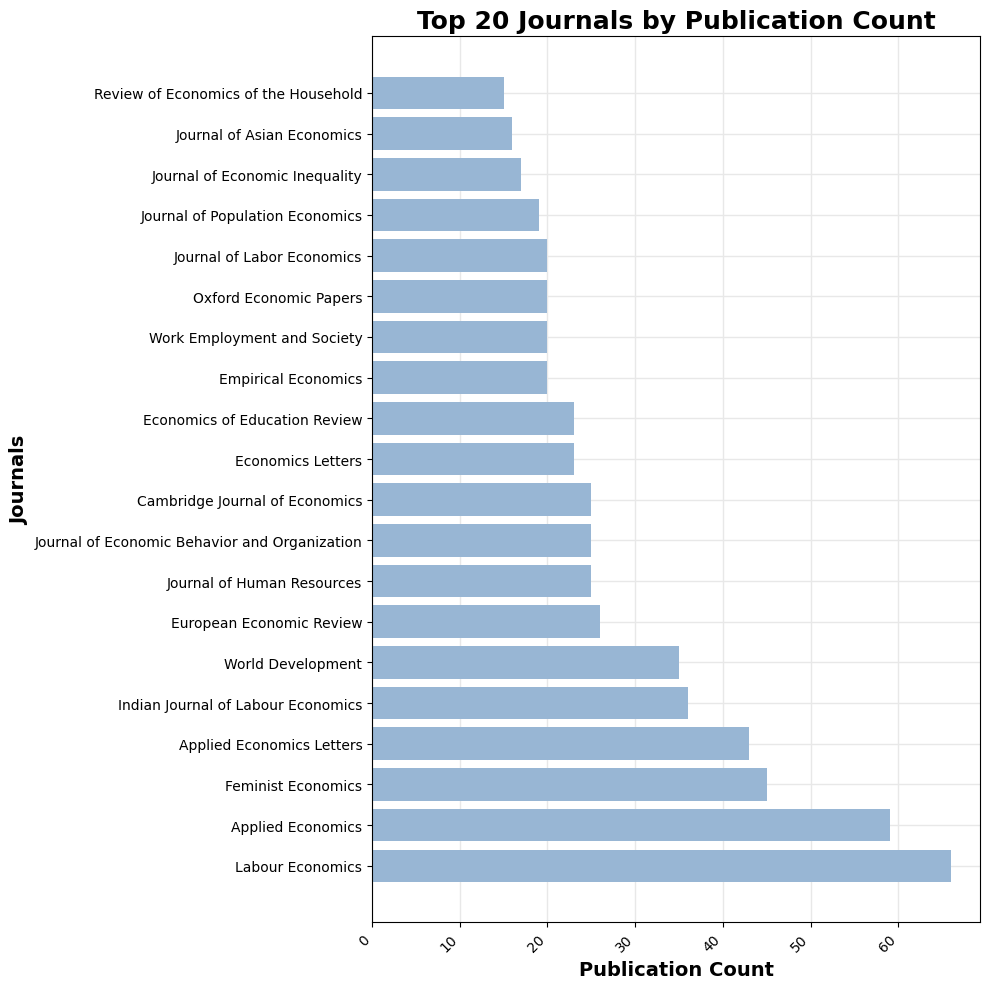

In [8]:
# Top journals by publication count

top_journals = df_main["publication_name"].value_counts().head(20)
other_journals = df_main["publication_name"].value_counts().iloc[20:].sum()
journals = pd.concat([top_journals, pd.Series({"Other journals": other_journals})])

# latex_table = journals.to_latex()
# print(latex_table)

# fig_all = plt.figure(figsize=(10, 10))
# plt.pie(journals.values, labels=journals.index, autopct="%1.1f%%", startangle=140)
# plt.title("Distribution of Journals by Publication Count")
# save_figure("journal_distribution.png", dpi=300)
# plt.show()


fig_20, ax_journals = plt.subplots(figsize=(10, 10))

ax_journals.grid(True, which="major", color="#e8e8e8", linewidth=1)
ax_journals.barh(range(len(top_journals)), top_journals.values, tick_label=top_journals.index, color="#98b6d4")
ax_journals.set_axisbelow(True)
ax_journals.set_title("Top 20 Journals by Publication Count", fontsize=18, fontweight="bold")
ax_journals.set_xlabel("Publication Count", fontsize=14, fontweight="bold")
ax_journals.set_ylabel("Journals", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_figure("top_20_journal.png", dpi=300)
plt.show()


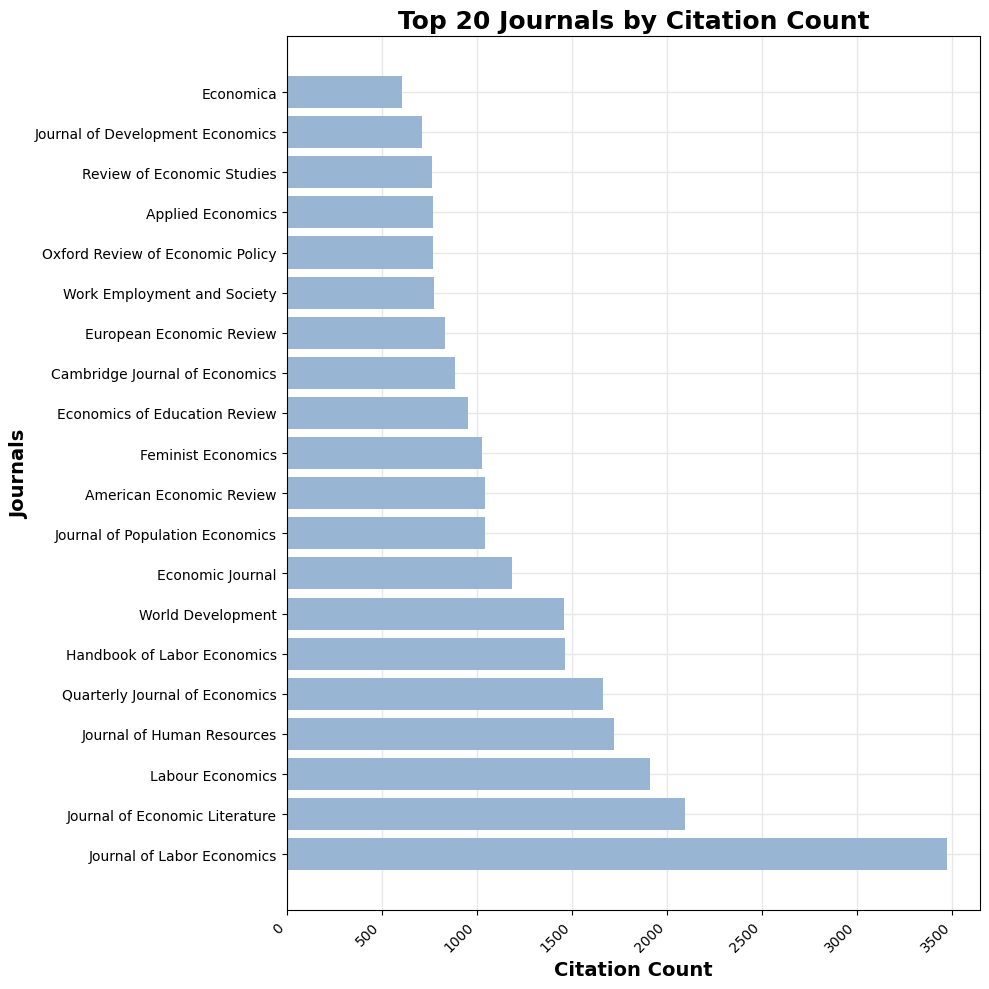

In [9]:
# Top journals by citation count
top_journals_cited = df_main.groupby("publication_name")["citedby_count"].sum().sort_values(ascending=False).head(20)

fig_20, ax_journals = plt.subplots(figsize=(10, 10))

ax_journals.grid(True, which="major", color="#e8e8e8", linewidth=1)
ax_journals.barh(range(len(top_journals_cited)), top_journals_cited.values, tick_label=top_journals_cited.index, color="#98b6d4")
ax_journals.set_axisbelow(True)
ax_journals.set_title("Top 20 Journals by Citation Count", fontsize=18, fontweight="bold")
ax_journals.set_xlabel("Citation Count", fontsize=14, fontweight="bold")
ax_journals.set_ylabel("Journals", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
save_figure("top_20_journal_cited.png", dpi=300)
plt.show()


## 1.3 Top Authors


In [10]:
author_citations = {}
author_publications = {}
author_labels = {}

for _, row in df_main.iterrows():
    if pd.notna(row["authors"]) and pd.notna(row["author_ids"]):
        pairs = parse_author_pairs(row["authors"], row["author_ids"])

        seen_ids = set()
        unique_pairs = []
        for aid, name in pairs:
            if aid not in seen_ids:
                unique_pairs.append((aid, name))
                seen_ids.add(aid)

        for aid, name in unique_pairs:
            author_labels[aid] = name
            author_publications[aid] = author_publications.get(aid, 0) + 1

            if pd.notna(row.get("citedby_count", None)):
                author_citations[aid] = author_citations.get(aid, 0) + row["citedby_count"]
            else:
                author_citations[aid] = author_citations.get(aid, 0)

sorted_authors = sorted(author_citations.items(), key=lambda x: x[1], reverse=True)

top_cited_authors_df = pd.DataFrame([
    (
        aid,
        author_labels.get(aid, aid),
        author_publications.get(aid, 0),
        citations
    )
    for aid, citations in sorted_authors[:20]
], columns=["Author_ID", "Author", "Publications", "Citations"])

print(top_cited_authors_df.to_latex(index=False))


\begin{tabular}{llrr}
\toprule
Author_ID & Author & Publications & Citations \\
\midrule
7004255822 & Blau, F. D. & 10 & 3858 \\
7101873406 & Kahn, L. M. & 10 & 3858 \\
7006709011 & Card, David & 4 & 1282 \\
6602414825 & Altonji, Joseph G. & 1 & 1188 \\
7101662421 & Blank, Rebecca M. & 1 & 1188 \\
7202623033 & Albrecht, James W. & 6 & 945 \\
6603717054 & Vroman, Susan B. & 5 & 911 \\
7003972408 & DiNardo, John E. & 1 & 855 \\
7004050059 & Fortin, Nicole M. & 5 & 748 \\
7003819055 & Winter-Ebmer, Rudolf & 5 & 636 \\
14018682500 & Weichselbaumer, Doris & 4 & 577 \\
8961803300 & Petrongolo, Barbara & 3 & 566 \\
18635612700 & Wiswall, Matthew & 3 & 561 \\
7201477258 & Björklund, Anders & 1 & 503 \\
6603249168 & Olivetti, Claudia & 5 & 492 \\
8450457100 & Black, Sandra E. & 2 & 488 \\
7201728318 & Booth, Alison L. & 4 & 474 \\
37014229300 & Zafar, Basit & 3 & 466 \\
6603193236 & Aizer, Anna & 1 & 461 \\
7101816484 & Manning, Alan & 3 & 442 \\
\bottomrule
\end{tabular}



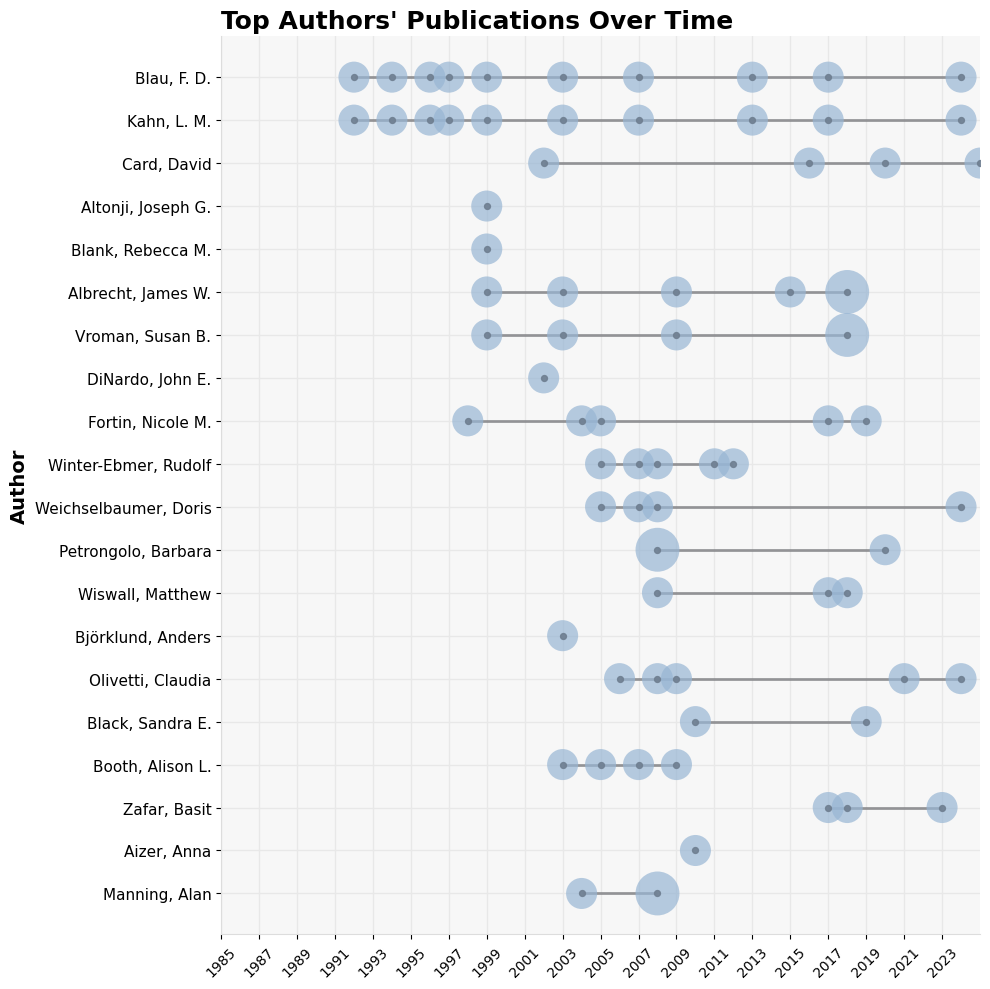

In [11]:
# Top authors' publications over time

fig, ax = plt.subplots(figsize=(10, 10))
ax.set_facecolor("#f7f7f7")
ax.grid(True, which="major", color="#e8e8e8", linewidth=1)
ax.set_axisbelow(True)

y_map = {
    author: len(top_cited_authors_df) - i
    for i, author in enumerate(top_cited_authors_df["Author"])
}

for author in top_cited_authors_df["Author"]:

    # 用 author_id 精确匹配，而不是 str.contains(author name)
    author_id = top_cited_authors_df.loc[
        top_cited_authors_df["Author"] == author, "Author_ID"
    ].iloc[0]

    sub = df_main[
        df_main["author_ids"].fillna("").apply(
            lambda x: author_id in [aid.strip() for aid in str(x).split(";")]
        )
    ]

    if len(sub) > 0:
        y = y_map[author]

        # count publications per year
        year_counts = (
            sub.groupby("year")
               .size()
               .reset_index(name="pub_count")
               .sort_values("year")
        )

        xmin = year_counts["year"].min()
        xmax = year_counts["year"].max()

        ax.hlines(
            y, xmin, xmax,
            color="#6f7074",
            alpha=0.7,
            linewidth=2
        )

        ax.scatter(
            year_counts["year"],
            [y] * len(year_counts),
            s=year_counts["pub_count"] * 500,
            color="#98b6d4",
            alpha=0.7,
            edgecolor="none",
            zorder=3
        )

        ax.scatter(
            year_counts["year"],
            [y] * len(year_counts),
            s=18,
            color="#6f7f91",
            alpha=0.9,
            zorder=4
        )

ax.set_yticks([y_map[a] for a in top_cited_authors_df["Author"]])
ax.set_yticklabels(top_cited_authors_df["Author"], fontsize=11)

ax.set_xlim(1985, 2025)
ax.set_xticks(range(1985, 2025, 2))
plt.xticks(rotation=45)

ax.set_ylabel("Author", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_title(
    "Top Authors' Publications Over Time",
    loc="left",
    fontsize=18,
    fontweight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#dddddd")
ax.spines["bottom"].set_color("#dddddd")

plt.tight_layout()
save_figure("top_cited_authors_publications.png", dpi=300)
plt.show()


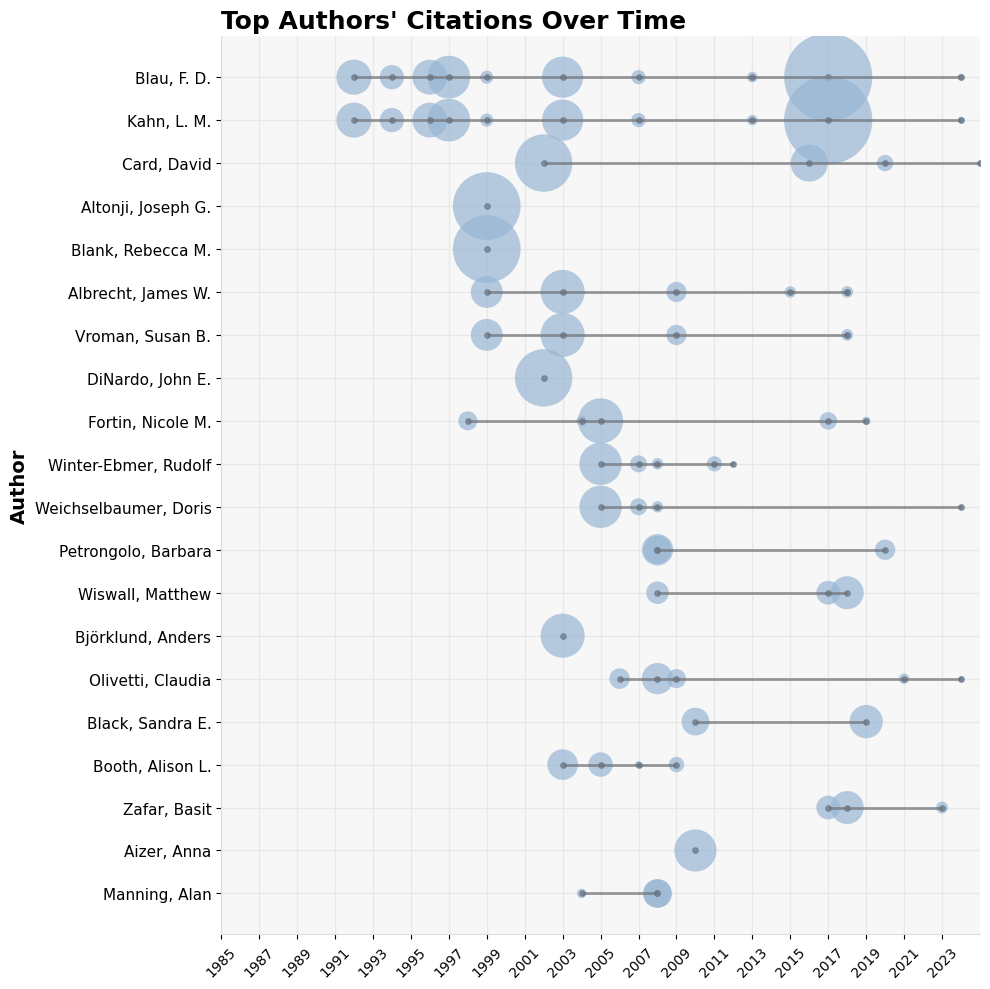

In [12]:
# Top authors' citations over time
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_facecolor("#f7f7f7")
ax.grid(True, which="major", color="#e8e8e8", linewidth=1)
ax.set_axisbelow(True)
y_map = {
    author: len(top_cited_authors_df) - i
    for i, author in enumerate(top_cited_authors_df["Author"])
}

for author in top_cited_authors_df["Author"]:

    author_id = top_cited_authors_df.loc[
        top_cited_authors_df["Author"] == author, "Author_ID"
    ].iloc[0]

    sub = df_main[
        df_main["author_ids"].fillna("").apply(
            lambda x: author_id in [aid.strip() for aid in str(x).split(";")]
        )
    ]

    if len(sub) > 0:
        xmin = sub["year"].min()
        xmax = sub["year"].max()
        y = y_map[author]
        ax.hlines(y, xmin, xmax, color="#6f7074", alpha=0.7, linewidth=2)
        y_coords = [y] * len(sub)
        ax.scatter(sub["year"], y_coords, s=sub["citedby_count"] * 2, color="#98b6d4", alpha=0.7, edgecolor="none")
        ax.scatter(sub["year"], y_coords,  s=15, color="#6f7f91", alpha=0.8)
ax.set_yticks([y_map[a] for a in top_cited_authors_df["Author"]])
ax.set_yticklabels(top_cited_authors_df["Author"], fontsize=11)

ax.set_xlim(1985, 2025)
ax.set_xticks(range(1985, 2025, 2))
plt.xticks(rotation=45)

ax.set_ylabel("Author", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_title("Top Authors' Citations Over Time", loc="left", fontsize=18, fontweight="bold")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#dddddd")
ax.spines["bottom"].set_color("#dddddd")

plt.tight_layout()
save_figure("top_cited_authors_citations.png", dpi=300)
plt.show()


## 1.4 Top-Cited Papers

Most-cited papers by total citations and citations per year.


In [13]:
top_cited_papers = df_main[["title", "authors", "citedby_count", "year"]].dropna().sort_values("citedby_count", ascending=False).head(20)
top_cited_papers = top_cited_papers.rename(columns={
    "title": "Title",
    "authors": "Author",
    "citedby_count": "Citations",
    "year": "Year"
})
print(top_cited_papers.to_latex(index=False))


\begin{tabular}{llrr}
\toprule
Title & Author & Citations & Year \\
\midrule
The gender wage gap: Extent, trends, & explanations & Blau, Francine D.;Kahn, Lawrence M. & 2017 & 2017 \\
Chapter 48 Race and gender in the labor market & Altonji, Joseph G.;Blank, Rebecca M. & 1188 & 1999 \\
Skill-biased technological change and rising wage inequality: Some problems and puzzles & Card, David;DiNardo, John E. & 855 & 2002 \\
Gender role attitudes and the labour-market outcomes of women across OECD countries & Fortin, Nicole M. & 528 & 2005 \\
Is There a Glass Ceiling in Sweden? & Albrecht, James;Björklund, Anders;Vroman, Susan & 503 & 2003 \\
Swimming upstream: Trends in the gender wage differential in the 1980s & Blau, Francine D.;Kahn, Lawrence M. & 474 & 1997 \\
A meta-analysis of the international gender wage gap & Weichselbaumer, Doris;Winter-Ebmer, Rudolf & 464 & 2005 \\
The gender wage gap and domestic violence & Aizer, Anna & 461 & 2010 \\
Understanding International Differences in th

## 1.5 H-index


In [14]:
# H-index for the entire dataset
def h_index(citations):
    citations = sorted(citations, reverse=True)
    h = 0
    for i, c in enumerate(citations):
        if c >= i + 1:
            h = i + 1
        else:
            break
    return h

h = h_index(df_main["citedby_count"].dropna().tolist())
print(f"The H-index is: {h}")

# H-index for top authors
# Create a series with author as index and citation count as value
author_citations_list = []
for _, row in df_main.iterrows():
    if pd.notna(row["authors"]) and pd.notna(row["author_ids"]) and pd.notna(row["citedby_count"]):

        authors = [a.strip() for a in str(row["authors"]).split(";") if a.strip()]
        author_ids = [aid.strip() for aid in str(row["author_ids"]).split(";") if aid.strip()]

        n = min(len(authors), len(author_ids))

        for i in range(n):
            author = authors[i]
            author_id = author_ids[i]

            author_citations_list.append({ # pyright: ignore[reportUndefinedVariable]
                "author_id": author_id,
                "author": author,
                "citations": row["citedby_count"]
            })

author_df = pd.DataFrame(author_citations_list)
author_h_indices = author_df.groupby("author")["citations"].apply(h_index)
print(author_h_indices.sort_values(ascending=False).head(20).to_latex())


The H-index is: 93
\begin{tabular}{lr}
\toprule
 & citations \\
author &  \\
\midrule
Blau, Francine D. & 8 \\
Kahn, Lawrence M. & 8 \\
Dong, Xiao Yuan & 6 \\
Ma, Xinxin & 6 \\
Reilly, Barry & 6 \\
Mumford, Karen & 6 \\
Gradín, Carlos & 5 \\
Fortin, Nicole M. & 5 \\
Hirsch, Boris & 5 \\
Olivetti, Claudia & 5 \\
Meng, Xin & 5 \\
Meurs, Dominique & 5 \\
Dolado, Juan J. & 4 \\
Weichselbaumer, Doris & 4 \\
Cortés, Patricia & 4 \\
Booth, Alison L. & 4 \\
Cremer, Helmuth & 4 \\
Simón, Hipólito & 4 \\
Seguino, Stephanie & 4 \\
Joshi, Heather & 4 \\
\bottomrule
\end{tabular}



## 1.6 G-index


In [15]:
# g-index for the entire dataset
def g_index(citations):
    citations = sorted(citations, reverse=True)
    g = 0
    total_citations = 0
    for i, c in enumerate(citations):
        total_citations += c
        if total_citations >= (i + 1) ** 2:
            g = i + 1
        else:
            break
    return g
g = g_index(df_main["citedby_count"].dropna().tolist())
print(f"The G-index is: {g}")

# g-index for top authors
author_g_indices = author_df.groupby("author")["citations"].apply(g_index)
print(author_g_indices.sort_values(ascending=False).head(20).to_latex())


The G-index is: 159
\begin{tabular}{lr}
\toprule
 & citations \\
author &  \\
\midrule
Ma, Xinxin & 11 \\
Blau, Francine D. & 8 \\
Kahn, Lawrence M. & 8 \\
Hirsch, Boris & 8 \\
Reilly, Barry & 7 \\
Mumford, Karen & 6 \\
Meurs, Dominique & 6 \\
Dong, Xiao Yuan & 6 \\
Albrecht, James & 5 \\
Olivetti, Claudia & 5 \\
Meng, Xin & 5 \\
Winter-Ebmer, Rudolf & 5 \\
Rycx, François & 5 \\
Tyrowicz, Joanna & 5 \\
Schnabel, Claus & 5 \\
Thornton, Robert J. & 5 \\
Kidd, Michael P. & 5 \\
Joshi, Heather & 5 \\
Kaya, Ezgi & 5 \\
Cremer, Helmuth & 5 \\
\bottomrule
\end{tabular}



## 1.7 Top Institutions


In [16]:
# By publication count
top_institutions_by_pubs = (
	df_main_long.groupby("parsed_author_affiliation_name")
	.size()
	.sort_values(ascending=False)
	.head(20)
)

# By citation count
institutions_by_citations=df_main_long.groupby("parsed_author_affiliation_name")["citedby_count"].sum()
top_institutions_by_citations = institutions_by_citations.sort_values(ascending=False).head(20)

# Rename parsed_author_affiliation_name to Institution.
top_institutions_by_pubs.index.name = "Institution"
top_institutions_by_citations.index.name = "Institution"

latex_pubs = top_institutions_by_pubs.to_frame(name="Publications").to_latex()
latex_cits = top_institutions_by_citations.to_frame(name="Citations").to_latex()

latex_combined = f"""
\\begin{{table}}[htbp]
\\centering
\\begin{{minipage}}{{0.45\\textwidth}}
{latex_pubs}
\\end{{minipage}}
\\hfill
\\begin{{minipage}}{{0.45\\textwidth}}
{latex_cits}
\\end{{minipage}}
\\caption{{Top institutions by publications and citations}}
\\end{{table}}
"""

print(latex_combined)



\begin{table}[htbp]
\centering
\begin{minipage}{0.45\textwidth}
\begin{tabular}{lr}
\toprule
 & Publications \\
Institution &  \\
\midrule
The World Bank, USA & 34 \\
Friedrich-Alexander-Universität Erlangen-Nürnberg & 28 \\
Georgetown University & 21 \\
The Australian National University & 20 \\
London School of Economics and Political Science & 20 \\
Tartu Ülikool & 19 \\
University of Warsaw & 19 \\
Johannes Kepler University Linz & 17 \\
Université Libre de Bruxelles & 16 \\
University of Oxford & 16 \\
Universidad Rey Juan Carlos & 16 \\
IZA - Institute of Labor Economics & 16 \\
Universidade de Vigo & 15 \\
NHH Norwegian School of Economics & 14 \\
Institute for Employment Research, Nuremberg & 12 \\
University of Aberdeen & 12 \\
Universidad de Málaga & 12 \\
University of York & 12 \\
University of Cambridge & 12 \\
University of the Witwatersrand, Johannesburg & 12 \\
\bottomrule
\end{tabular}

\end{minipage}
\hfill
\begin{minipage}{0.45\textwidth}
\begin{tabular}{lr}
\toprul

## 1.8 Top Countries


In [17]:
# By publication count
countries_by_pubs = (
	df_main_long.groupby("parsed_author_affiliation_country")
	.size()
	.sort_values(ascending=False)
)

top_countries_by_pubs = countries_by_pubs.head(20)

# By citation count
countries_by_citations = (
	df_main_long.groupby("parsed_author_affiliation_country")["citedby_count"]
	.sum()
	.sort_values(ascending=False)
)
top_countries_by_citations = countries_by_citations.head(20)

# Rename parsed_author_affiliation_country to Country.
top_countries_by_pubs.index.name = "Country"
top_countries_by_citations.index.name = "Country"

latex_pubs = top_countries_by_pubs.to_frame(name="Publications").to_latex()
latex_cits = top_countries_by_citations.to_frame(name="Citations").to_latex()

# Table
latex_combined = f"""
\\begin{{table}}[htbp]
\\centering
\\begin{{minipage}}{{0.45\\textwidth}}
{latex_pubs}
\\end{{minipage}}
\\hfill
\\begin{{minipage}}{{0.45\\textwidth}}
{latex_cits}
\\end{{minipage}}
\\caption{{Top countries by publications and citations}}
\\end{{table}}
"""

#print(latex_combined)


Number of countries not found: 0
          country value iso_a3
0   United States   789    USA
1  United Kingdom   309    GBR
2         Germany   202    DEU
3           Spain   183    ESP
4           China   169    CHN
                      ADMIN ADM0_A3 iso_a3 value
4  United States of America     USA    USA   789


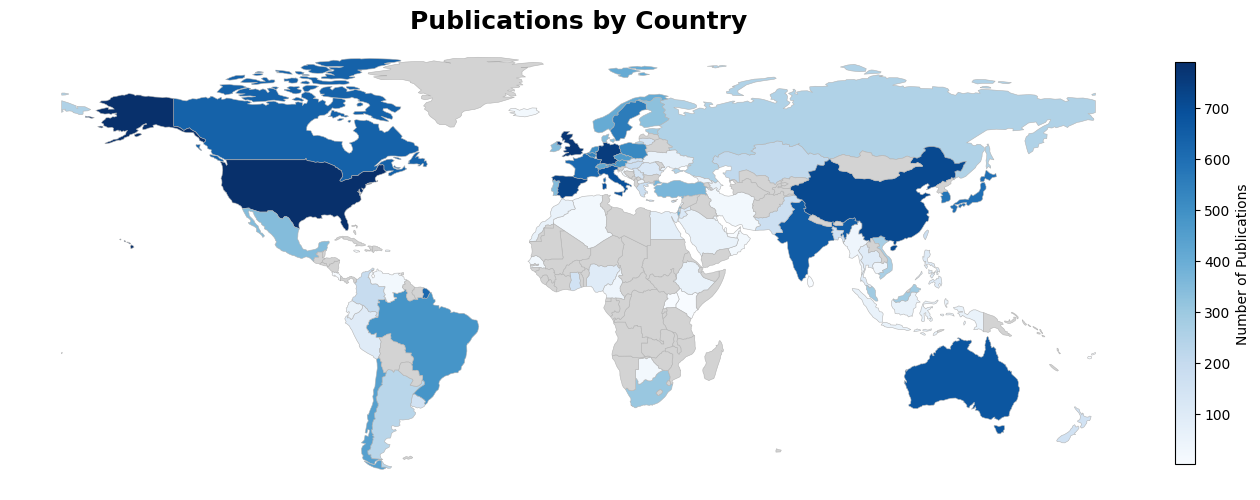

In [18]:
# World heatmap
df = pd.DataFrame(countries_by_pubs.reset_index().values, columns=["country", "value"])
df["iso_a3"] = df["country"].apply(lambda x: coco.convert(names=x, to="ISO3"))
print(f"Number of countries not found: {len(df[df['iso_a3'] == 'not found'])}")
print(df.head())


world = gpd.read_file("https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip")
merged = world.merge(df, left_on="ISO_A3_EH", right_on="iso_a3", how="left")
merged = merged[merged["ADMIN"] != "Antarctica"]
print(merged.loc[merged["ADMIN"] == "United States of America",
           ["ADMIN", "ADM0_A3", "iso_a3", "value"]])

vmax = merged["value"].quantile(0.95)
fig, ax = plt.subplots(1, 1, figsize=(14, 7))

# map without colorbar
merged.plot(
    column="value",
    cmap="Blues",
    linewidth=0.4,
    ax=ax,
    edgecolor="0.7",
    legend=False,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

# build colorbar
norm = mpl.colors.Normalize(
    vmin=merged["value"].min(),
    vmax=merged["value"].max()
)

sm = mpl.cm.ScalarMappable(cmap="Blues", norm=norm)
sm._A = []

cbar = fig.colorbar(
    sm,
    ax=ax,
    shrink=0.6,
    aspect=20,
    pad=0.02
)

cbar.set_label("Number of Publications")

ax.set_title("Publications by Country", fontsize=18, fontweight="bold")
ax.axis("off")

plt.tight_layout()
save_figure("publications_by_country_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


In [19]:
print("Total countries in your data:", len(df))
print("Matched countries:", merged["value"].notna().sum())
unmatched = df[~df["iso_a3"].isin(merged["iso_a3"])]
print(unmatched[["country", "iso_a3"]])
print(df[~df["iso_a3"].isin(world["ISO_A3_EH"])])


Total countries in your data: 92
Matched countries: 89
        country iso_a3
30    Hong Kong    HKG
35    Singapore    SGP
88  Saint Lucia    LCA
        country value iso_a3
30    Hong Kong    23    HKG
35    Singapore    18    SGP
88  Saint Lucia     1    LCA


# 2. Science Mapping

Structure and dynamics of scholarly knowledge in the dataset.


## 2.1 Keywords


['gender wage gap', 'gender', 'gender pay gap', 'discrimination', 'wages', 'wage gap', 'gender gap', 'quantile regression', 'decomposition', 'human capital', 'gender inequality', 'inequality', 'wage inequality', 'wage differentials', 'education', 'glass ceiling', 'china', 'j16', 'employment', 'gender discrimination']


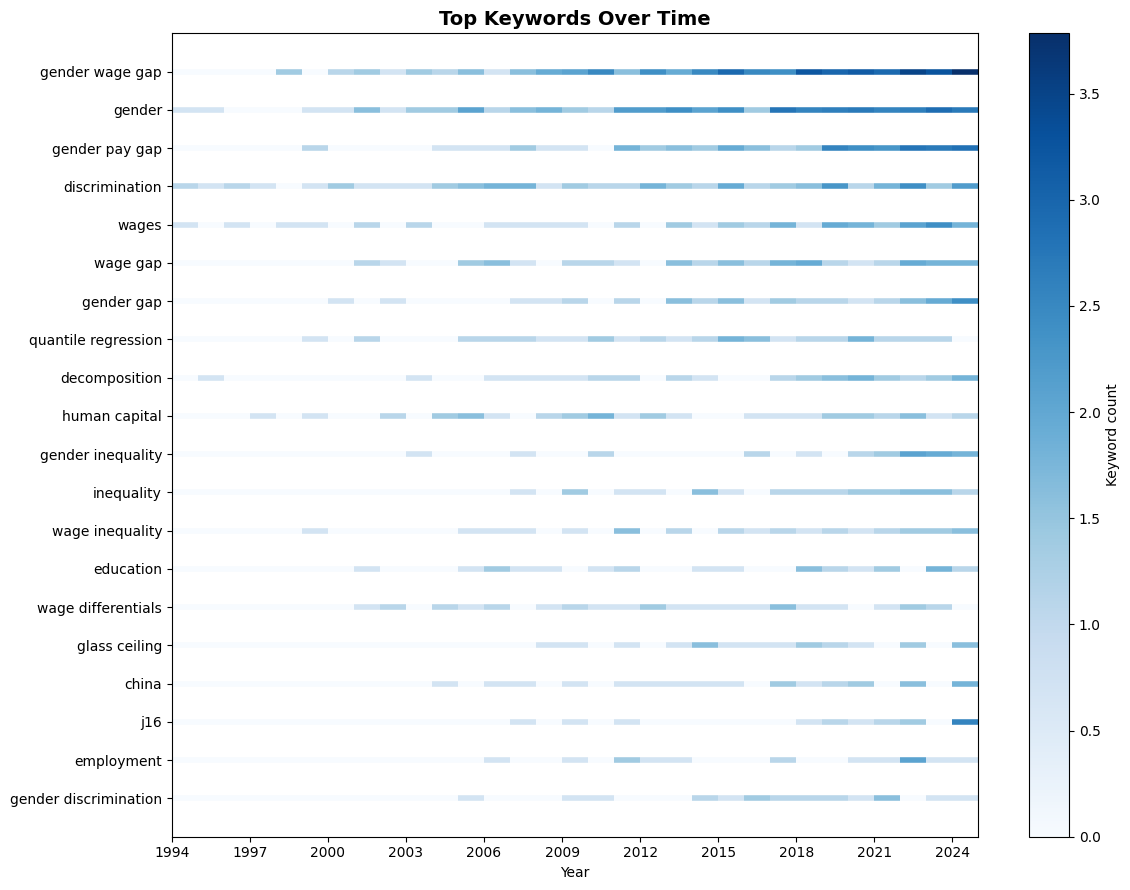

In [20]:
# Keyword dataframe
df_keywords = df_main[["year", "keywords"]].dropna().copy()
df_keywords = df_keywords.assign(keywords=df_keywords["keywords"].str.split("|")).explode("keywords")
df_keywords["keywords"] = df_keywords["keywords"].str.strip().str.lower()
df_keywords = df_keywords[df_keywords["keywords"] != ""]
df_keywords["year"] = pd.to_numeric(df_keywords["year"], errors="coerce")
df_keywords = df_keywords.dropna(subset=["year"])
df_keywords["year"] = df_keywords["year"].astype(int)

keyword_year_counts = (
    df_keywords
    .groupby(["keywords", "year"])
    .size()
    .reset_index(name="count")
)


# Get the top 20 keywords by total count across all years.
top_n = 20
top_keywords = (
    keyword_year_counts.groupby("keywords")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)
print(top_keywords.to_list())  # Note: j16 = Economics of Gender.
plot_data = keyword_year_counts[keyword_year_counts["keywords"].isin(top_keywords)].copy()

heatmap_data = (
    plot_data
    .pivot(index="keywords", columns="year", values="count")
    .fillna(0)
)

heatmap_data = heatmap_data.loc[heatmap_data.sum(axis=1).sort_values(ascending=False).index]
all_years = range(heatmap_data.columns.min(), heatmap_data.columns.max() + 1)
heatmap_data = heatmap_data.reindex(columns=all_years, fill_value=0)

# Apply log transformation to the counts for better color scaling.
plot_matrix = np.log1p(heatmap_data)

years = np.array(plot_matrix.columns)
keywords = plot_matrix.index.tolist()

fig, ax = plt.subplots(figsize=(12, 9))

cmap = plt.cm.Blues
norm = mpl.colors.Normalize(
    vmin=0,
    vmax=plot_matrix.values.max()
)

for i, kw in enumerate(keywords):
    counts = plot_matrix.loc[kw].values

    ax.hlines(y=i, xmin=years.min(), xmax=years.max(), linewidth=3, color="#e6e6e6", zorder=1)

    segments = []
    colors = []

    for j in range(len(years) - 1):
        x0, x1 = years[j], years[j + 1]
        segments.append([(x0, i), (x1, i)])
        colors.append(cmap(norm(counts[j])))

    lc = LineCollection(segments, colors=colors, linewidths=4, zorder=2)
    ax.add_collection(lc)

ax.set_yticks(range(len(keywords)))
ax.set_yticklabels(keywords, fontsize=10)
ax.set_xticks(years[::max(1, len(years) // 10)])
ax.set_xlim(years.min(), years.max())
ax.set_ylim(-1, len(keywords))
ax.invert_yaxis()

ax.set_xlabel("Year")
ax.set_title("Top Keywords Over Time", fontweight="bold", fontsize=14)

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Keyword count")

plt.tight_layout()
plt.show()
fig.savefig(PROJECT_DIR / "keyword_heatmap.png", dpi=300, bbox_inches="tight")


## 2.2 Co-citation Analysis


                       ref1                  ref2  weight
7032      Oaxaca, R. (1973)  Blinder, A.S. (1973)     195
19533  Blinder, A.S. (1973)    Neumark, D. (1988)      87
65136     Oaxaca, R. (1973)     Mincer, J. (1974)      86
18611     Oaxaca, R. (1973)    Neumark, D. (1988)      85
28039  Blinder, A.S. (1973)   Oaxaca, R.L. (1973)      85

Cluster 0
['Blau, F.D.; Kahn, L.M. (2007)', 'Addabbo, T.; Favaro, D. (2011)', 'Goldin, C. (2006)', 'Azmat, G.; Petrongolo, B. (2014)', 'Bertrand, M. (2011)', 'Card, D.; Cardoso, A.R.; Heining, J.; Kline, P. (2018)', 'Galor, O.; Weil, D.N. (1996)', 'Goldin, C. (2014)', 'Wilde, E.T.; Batchelder, L.; Ellwood, D.T. (2010)', 'Groshen, E.L. (1991)']

Cluster 1
['Arrow, K.J. (1973)', 'Machado, J.A.F.; Mata, J. (2005)', 'Fortin, N.; Lemieux, T.; Firpo, S. (2011)', 'Heckman, J.J. (1979)', 'Phelps, E.S. (1972)', 'Oaxaca, R.; Ransom, M. (1994)', 'Heckman, J. (1979)', 'Aigner, D.J.; Cain, G.G. (1977)', 'Mincer, J.; Ofek, H. (1982)', 'Mincer, J.; Polachek,

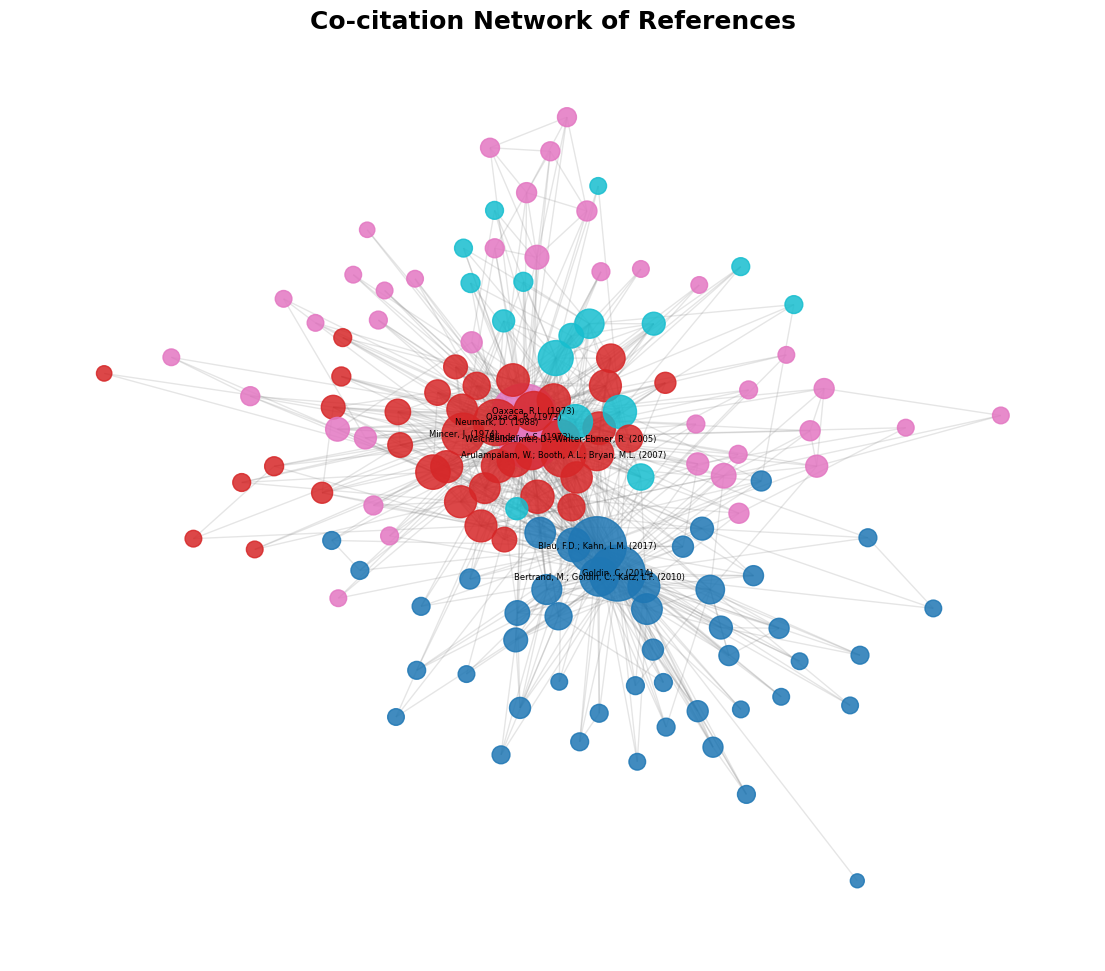

In [21]:
co_citation_pairs = []
for refs in df_main["references"]:
    if pd.notna(refs):
        ref_list = [r.strip() for r in str(refs).split("|") if r.strip() != ""]
        ref_list = list(set(ref_list))  # Drop duplicates.
        pairs = combinations(ref_list, 2)
        co_citation_pairs.extend(pairs)

co_citation_counts = Counter(co_citation_pairs)
df_co = pd.DataFrame(
    [(a, b, w) for (a, b), w in co_citation_counts.items()],
    columns=["ref1", "ref2", "weight"]
)
df_co = df_co[df_co["weight"] >= 8].sort_values("weight", ascending=False)  # Keep pairs co-cited at least 8 times.
print(df_co.head())

G = nx.Graph()

for _, row in df_co.iterrows():
    G.add_edge(row["ref1"], row["ref2"], weight=row["weight"])

# 去掉孤立/很弱节点
degree_dict = dict(G.degree())
core_nodes = [n for n, d in degree_dict.items() if d >= 3]
G_core = G.subgraph(core_nodes).copy()

# 只保留最大连通子图
largest_cc = max(nx.connected_components(G_core), key=len)
G_core = G_core.subgraph(largest_cc).copy()

# 节点大小按 centrality
degree_centrality = nx.degree_centrality(G_core)
node_sizes = [
    3000 * degree_centrality[n] + 80
    for n in G_core.nodes()
]

# 边宽按共被引强度
edge_widths = [
    G_core[u][v]["weight"] * 1.15
    for u, v in G_core.edges()
]

# 布局
pos = nx.spring_layout(
    G_core,
    k=0.8,
    iterations=100,
    seed=42,
    weight="weight"
)

# Community detection with greedy modularity.
communities = community.greedy_modularity_communities(G_core)
node_cluster = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_cluster[node] = i
colors = [node_cluster[n] for n in G_core.nodes()]


plt.figure(figsize=(14, 12))

nx.draw_networkx_edges(
    G_core,
    pos,
    alpha=0.2,
    edge_color="gray"
)

nodes = nx.draw_networkx_nodes(
    G_core,
    pos,
    node_size=node_sizes,
    node_color=colors,
    cmap=plt.cm.tab10,   #颜色区分cluster
    alpha=0.85
)

top_label_nodes = sorted(
    degree_centrality,
    key=degree_centrality.get,
    reverse=True
)[:10]

nx.draw_networkx_labels(
    G_core,
    pos,
    labels={n: n for n in top_label_nodes},
    font_size=6,
    font_weight="light"
)

plt.title("Co-citation Network of References", fontsize=18, fontweight="bold")
plt.axis("off")

for i, comm in enumerate(communities):
    print(f"\nCluster {i}")
    print(list(comm)[:10])


## 2.3 Bibliographic Coupling


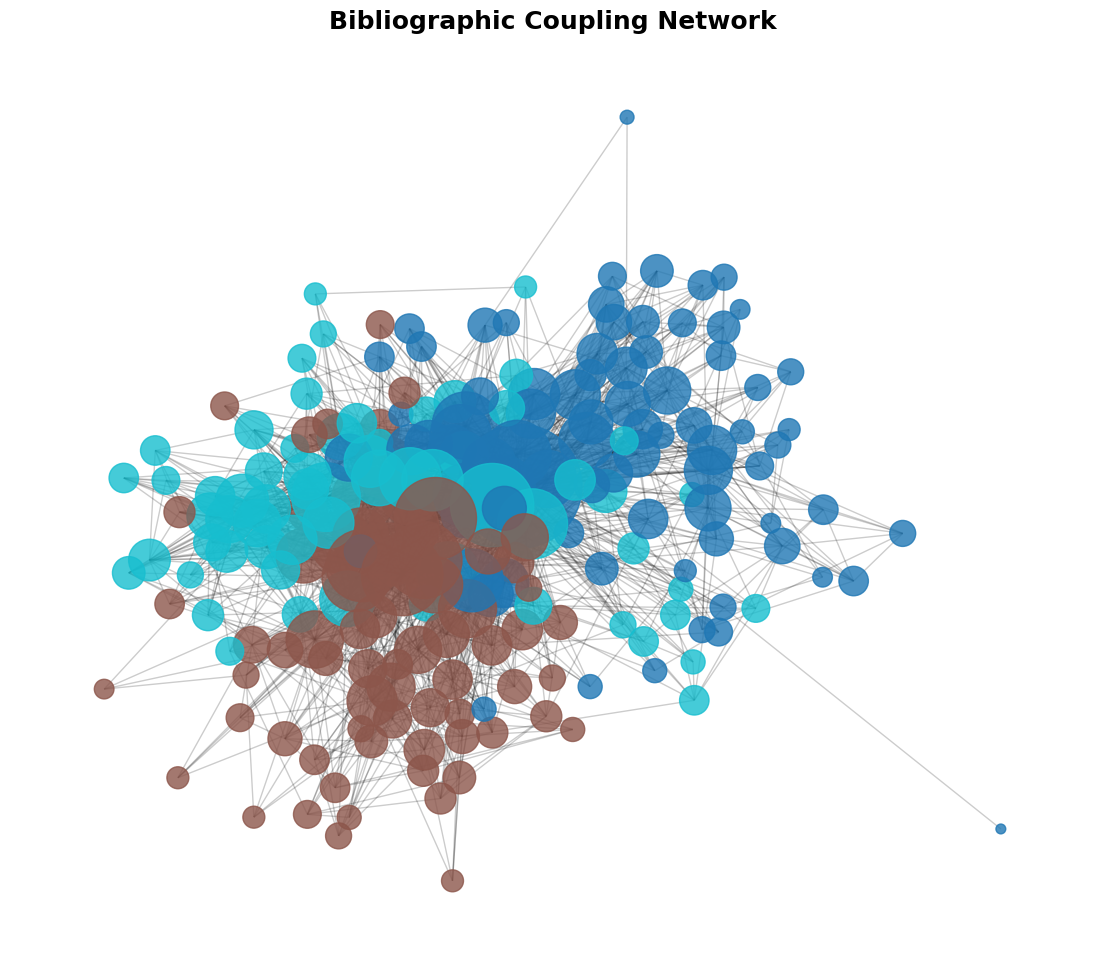

In [22]:
df_main["ref_list"] = df_main["references"].apply(
    lambda x: set(x.split(" | ")) if pd.notna(x) else set()
)

# Keep papers with at least 5 citations for clearer visualization.
df_sub = df_main[df_main["citedby_count"] >= 5 ].reset_index(drop=True)


edges = []

for i, j in itertools.combinations(range(len(df_sub)), 2):
    refs_i = df_sub.loc[i, "ref_list"]
    refs_j = df_sub.loc[j, "ref_list"]

    if len(refs_i) == 0 or len(refs_j) == 0:
        continue

    overlap = refs_i.intersection(refs_j)
    weight = len(overlap)

    if weight >= 5:
        edges.append({
            "paper1": df_sub.loc[i, "title"],
            "paper2": df_sub.loc[j, "title"],
            "weight": weight
        })

df_bc = pd.DataFrame(edges)

G_bc = nx.Graph()

for _, row in df_bc.iterrows():
    G_bc.add_edge(row["paper1"], row["paper2"], weight=row["weight"])

# 去掉低连接论文: degree 大于 8
nodes_to_keep = [n for n, d in G_bc.degree() if d >= 8]
G_bc = G_bc.subgraph(nodes_to_keep).copy()

# 最大连通子图
largest_cc = max(nx.connected_components(G_bc), key=len)
G_bc = G_bc.subgraph(largest_cc).copy()

# Community detection.
communities = community.greedy_modularity_communities(G_bc)
node_cluster = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_cluster[node] = i

pos = nx.spring_layout(G_bc, k=0.6, seed=42)

colors = [node_cluster[n] for n in G_bc.nodes()]
sizes = [G_bc.degree(n) * 50 for n in G_bc.nodes()]

plt.figure(figsize=(14, 12))

nx.draw_networkx_edges(G_bc, pos, alpha=0.2)

nx.draw_networkx_nodes(
    G_bc,
    pos,
    node_size=sizes,
    node_color=colors,
    cmap=plt.cm.tab10,
    alpha=0.8
)

plt.title("Bibliographic Coupling Network", fontsize=18, fontweight="bold")
plt.axis("off")
plt.show()


## 2.4 Co-word Analysis


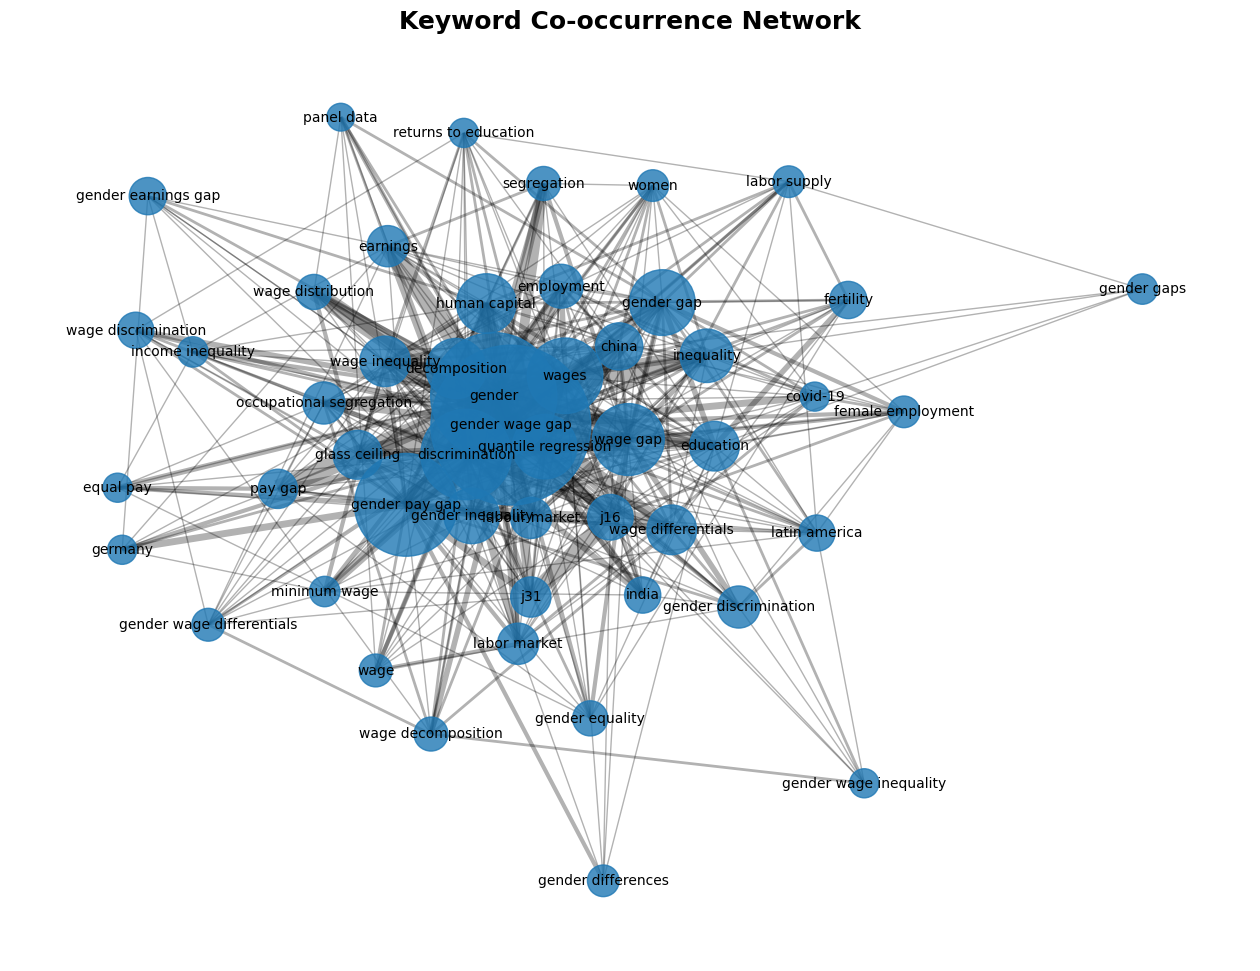

In [23]:
all_keywords = []

for kws in df_main["keywords"].dropna():
    words = [k.strip().lower() for k in kws.split("|")]
    words = [w for w in words if w != ""]
    all_keywords.extend(words)

# Count frequency.
keyword_freq = Counter(all_keywords)

# Top 50 keywords.
top_keywords = dict(keyword_freq.most_common(50))

Gk = nx.Graph()

for kws in df_main["keywords"].dropna():
    words = [k.strip().lower() for k in kws.split("|")]

    # Keep top keywords only.
    words = [w for w in words if w in top_keywords]

    # Remove duplicates within the same paper.
    words = list(set(words))

    for w1, w2 in combinations(words, 2):
        if Gk.has_edge(w1, w2):
            Gk[w1][w2]["weight"] += 1
        else:
            Gk.add_edge(w1, w2, weight=1)

plt.figure(figsize=(16, 12))

pos = nx.spring_layout(Gk, k=0.6, seed=42)

sizes = [keyword_freq[node]*40 for node in Gk.nodes()]
weights = [Gk[u][v]["weight"] for u,v in Gk.edges()]

nx.draw_networkx_nodes(Gk, pos, node_size=sizes, alpha=0.8)
nx.draw_networkx_edges(Gk, pos, width=weights, alpha=0.3)
nx.draw_networkx_labels(Gk, pos, font_size=10)

plt.title("Keyword Co-occurrence Network", fontsize=18, fontweight="bold")
plt.axis("off")
plt.show()


## 2.5 Co-authorship Analysis


Total authors: 2821
Total collaboration links: 2598
Subgraph authors: 50
Subgraph collaboration links: 36


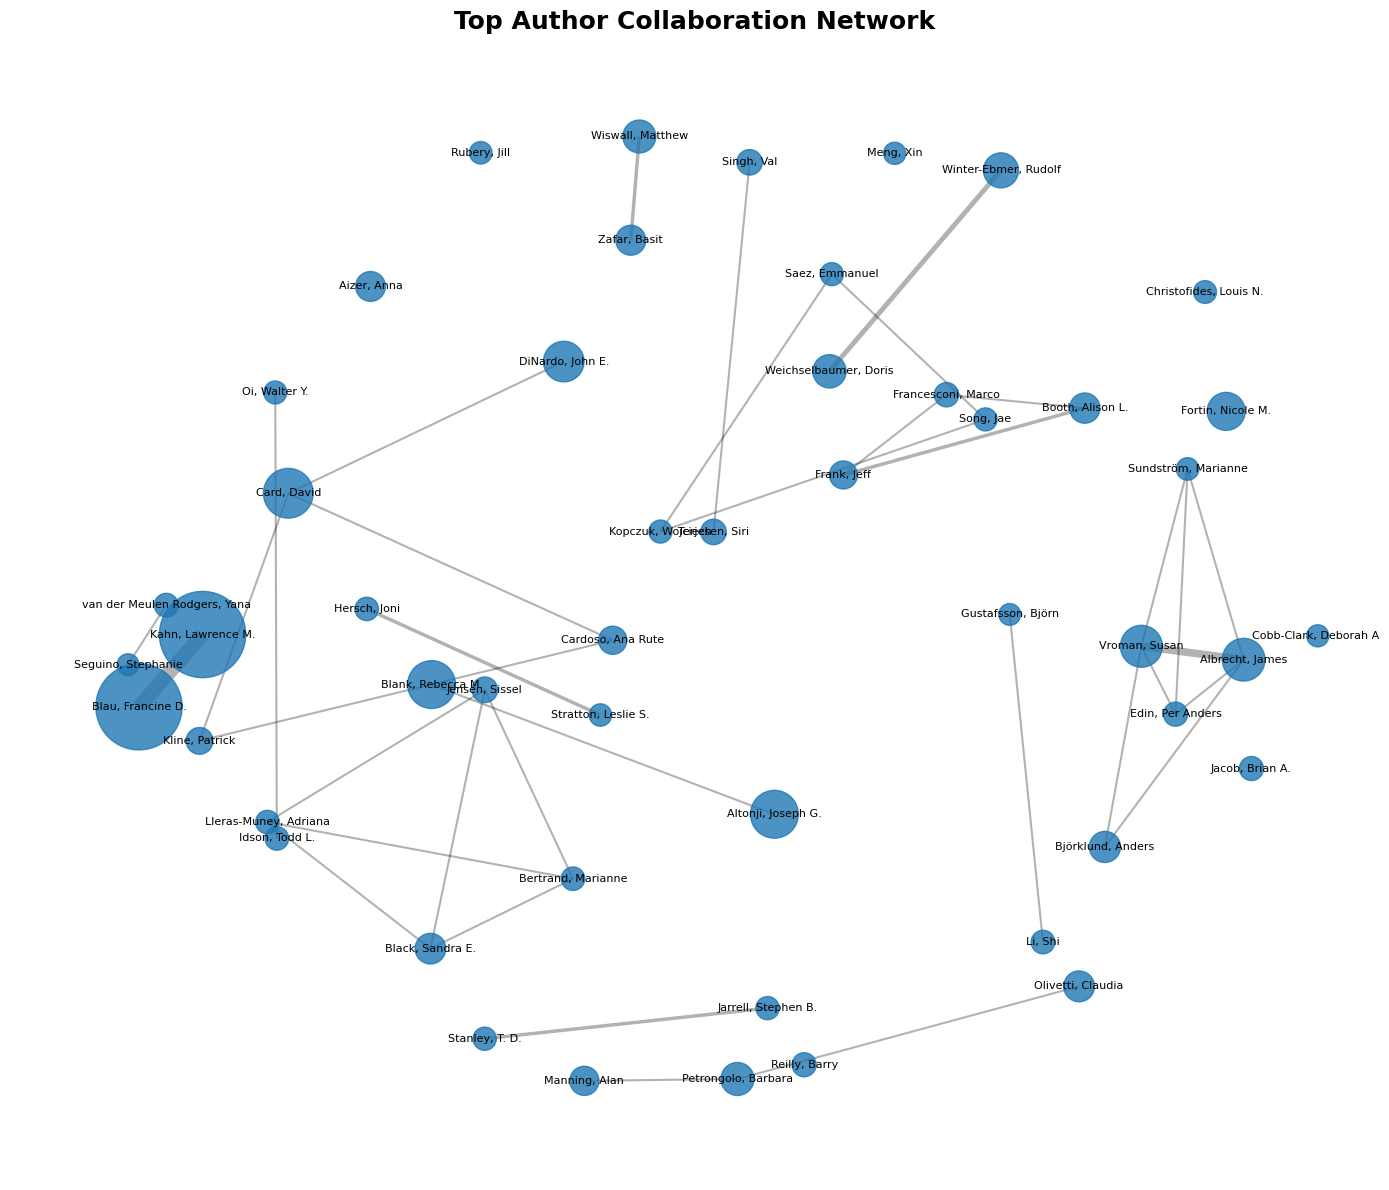

In [24]:
G = nx.Graph()

for _, row in df_main.iterrows():
    if pd.notna(row["authors"]) and pd.notna(row["author_ids"]):
        pairs = parse_author_pairs(row["authors"], row["author_ids"])

        # Drop duplicates within the same paper, keeping the first occurrence.
        unique_dict = {}
        for aid, name in pairs:
            if aid not in unique_dict:
                unique_dict[aid] = name

        author_nodes = list(unique_dict.items())  # [(aid, name), ...]

        # Add author_id as node, with name as an attribute.
        for aid, name in author_nodes:
            if not G.has_node(aid):
                G.add_node(aid, label=name)

        # Connect all author pairs from the same paper.
        for (aid1, _), (aid2, _) in combinations(author_nodes, 2):
            if G.has_edge(aid1, aid2):
                G[aid1][aid2]["weight"] += 1
            else:
                G.add_edge(aid1, aid2, weight=1)

print("Total authors:", G.number_of_nodes())
print("Total collaboration links:", G.number_of_edges())

# Optional graph: all authors and their collaborations.
# plt.figure(figsize=(14, 12))
# pos = nx.spring_layout(G, k=0.8, seed=42)
# nx.draw_networkx_nodes(G, pos, node_size=50, alpha=0.8
# )
# nx.draw_networkx_edges(G, pos, width=0.5, alpha=0.3)
# nx.draw_networkx_labels(G, pos, font_size=6)
# plt.title("Author Collaboration Network", fontsize=18, fontweight="bold")
# plt.axis("off")
# plt.tight_layout()
# save_figure("author_collaboration_network.png", dpi=300)
# plt.show()

# Subgraph: keep the top 50 cited authors for visualization.
top_50_cited_author_ids = [aid for aid, _ in sorted_authors[:50]]

G_sub = G.subgraph(top_50_cited_author_ids).copy()

print("Subgraph authors:", G_sub.number_of_nodes())
print("Subgraph collaboration links:", G_sub.number_of_edges())

plt.figure(figsize=(14, 12))

pos = nx.spring_layout(G_sub, k=0.8, seed=42)

node_sizes = [max(author_citations.get(n, 0), 50) for n in G_sub.nodes()]
edge_widths = [0.5 + G_sub[u][v]["weight"] for u, v in G_sub.edges()]
labels = {n: G_sub.nodes[n].get("label", n) for n in G_sub.nodes()}

nx.draw_networkx_nodes(
    G_sub,
    pos,
    node_size=node_sizes,
    alpha=0.8
)

nx.draw_networkx_edges(
    G_sub,
    pos,
    width=edge_widths,
    alpha=0.3
)

nx.draw_networkx_labels(
    G_sub,
    pos,
    labels=labels,
    font_size=8
)

plt.title("Top Author Collaboration Network",fontsize=18, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()


In [25]:
# Top authors by degree centrality (number of unique collaborators).
degree_centrality = nx.degree_centrality(G)
degree_centrality = {
    G.nodes[aid].get("label", aid): centrality
    for aid, centrality in degree_centrality.items()
} # Convert author_id to name for better readability.
top_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:20]
top_degree = pd.DataFrame(top_degree, columns=["Author", "Degree Centrality"]).to_latex(index=False)


# Top authors by betweenness centrality (authors who connect different groups).
betweenness_centrality = nx.betweenness_centrality(G, weight="weight")
betweenness_centrality = {
    G.nodes[aid].get("label", aid): centrality
    for aid, centrality in betweenness_centrality.items()
}
top_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:20]
top_betweenness = pd.DataFrame(top_betweenness, columns=["Author", "Betweenness Centrality"]).to_latex(index=False)


centrality_combined = f"""
\\begin{{table}}[htbp]
\\centering
\\scriptsize
\\begin{{minipage}}{{0.45\\textwidth}}
\\centering
{top_degree}
\\textit{{Note:}} Degree centrality reflects the number of direct collaboration ties an author has within the co-authorship network.
\\end{{minipage}}
\\hfill
\\begin{{minipage}}{{0.45\\textwidth}}
\\centering
{top_betweenness}
\\textit{{Note:}} Betweenness centrality identifies authors who act as brokers or bridges connecting otherwise separate collaboration groups.
\\end{{minipage}}
\\caption{{Top Authors by Degree and Betweenness Centrality}}
\\end{{table}}
"""

print(centrality_combined)



\begin{table}[htbp]
\centering
\scriptsize
\begin{minipage}{0.45\textwidth}
\centering
\begin{tabular}{lr}
\toprule
Author & Degree Centrality \\
\midrule
Dong, Xiao Yuan & 0.004255 \\
Rycx, François & 0.003901 \\
Joshi, Heather & 0.003546 \\
Card, David & 0.002837 \\
Li, Shi & 0.002837 \\
Baah-Boateng, William & 0.002837 \\
Albrecht, James & 0.002837 \\
Diana Deere, Carmen & 0.002837 \\
Masso, Jaan & 0.002482 \\
Paas, Tiiu & 0.002482 \\
Kokić, Erna & 0.002482 \\
Wagner, Laure & 0.002482 \\
García López del Amo, Ana & 0.002482 \\
Giering, Charlotte L. & 0.002482 \\
Ly Truong, Van & 0.002482 \\
Petrowsky, Hannes M. & 0.002482 \\
Husen, Onno M. & 0.002482 \\
Loschelder, David D. & 0.002482 \\
Bryson, Alex & 0.002482 \\
Reuben, Ernesto & 0.002482 \\
\bottomrule
\end{tabular}

\textit{Note:} Degree centrality reflects the number of direct collaboration ties an author has within the co-authorship network.
\end{minipage}
\hfill
\begin{minipage}{0.45\textwidth}
\centering
\begin{tabular}{lr}

## 2.6 Institution Collaboration


Number of institutions: 32
Number of collaboration links: 26


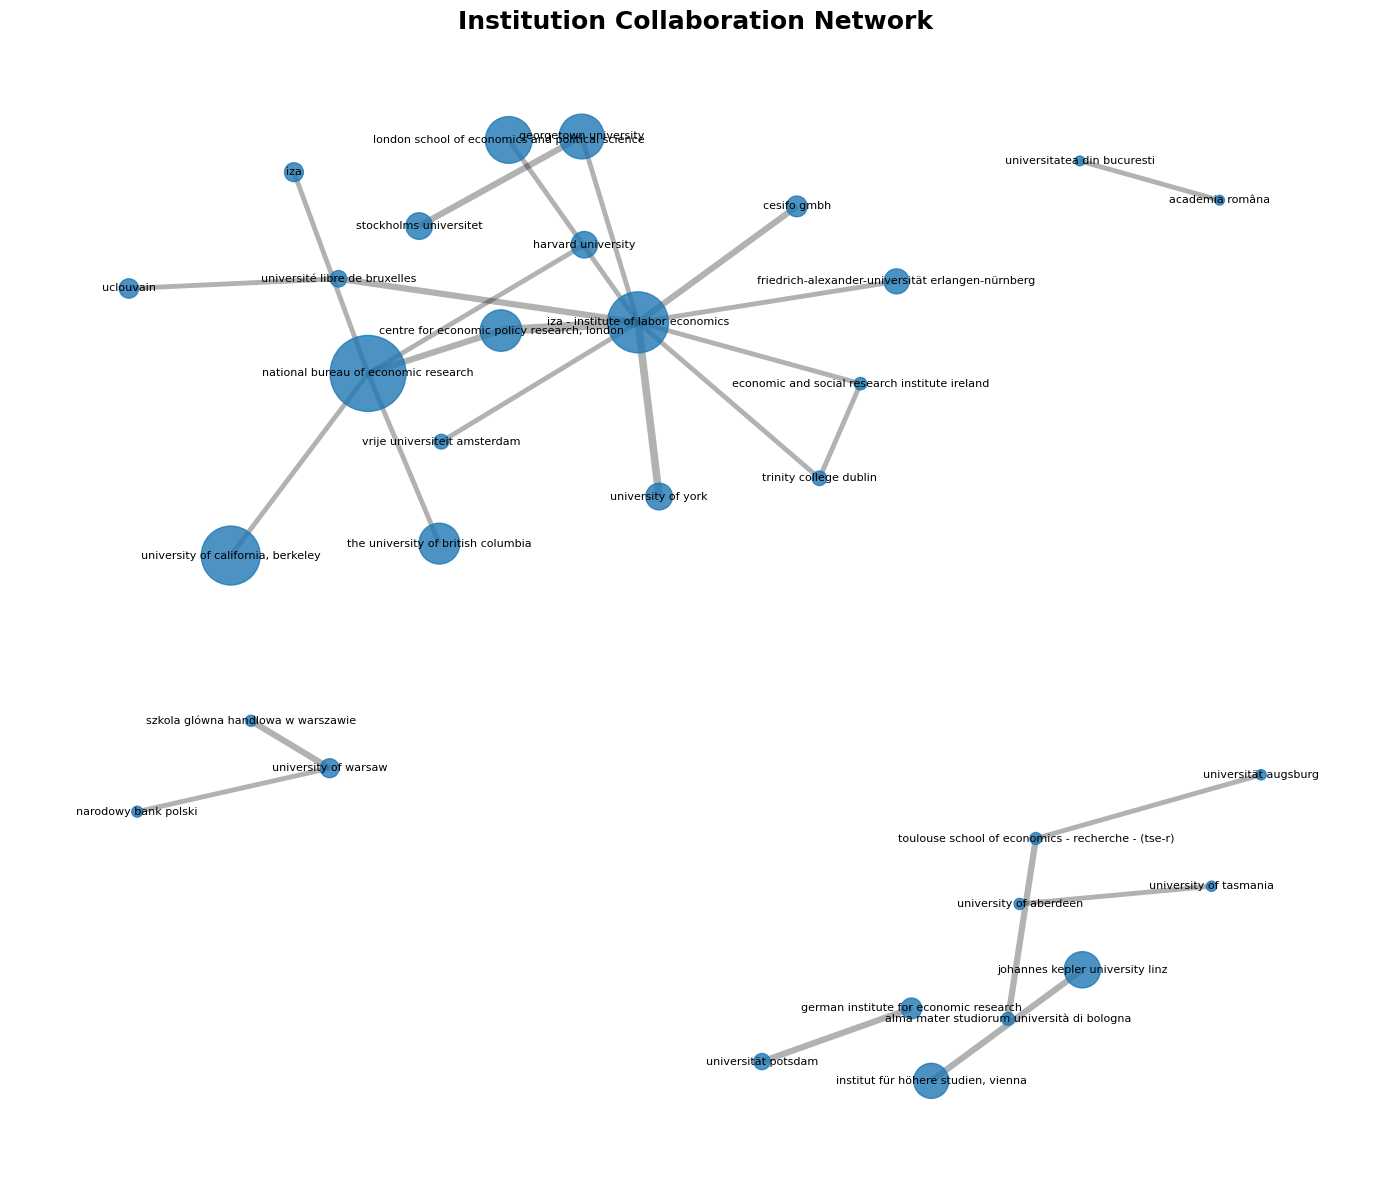

In [26]:
def extract_institution(x):
    if pd.isna(x):
        return []
    return [i.strip() for i in str(x).split(";")]

def clean_institution(x):
    return str(x).strip().lower()

# Split the string into a list.
df_main["affiliation_ids_list"] = df_main["affiliation_ids"].apply(extract_institution)
df_main["affiliation_names_list"] = df_main["affiliation_names"].apply(extract_institution).apply(
    lambda lst: list(set([clean_institution(i) for i in lst]))
)
df_main["affiliation_countries_list"] = df_main["affiliation_countries"].apply(extract_institution)

institution_pairs = []

for affils in df_main["affiliation_names_list"]:
    if len(affils) >= 2:
        institution_pairs.extend(itertools.combinations(sorted(affils), 2))

# Count collaboration frequency.
pair_counts = Counter(institution_pairs)

df_inst_edges = pd.DataFrame(
    [(a, b, w) for (a, b), w in pair_counts.items()],
    columns=["institution_1", "institution_2", "weight"]
)

df_inst_edges = df_inst_edges.sort_values("weight", ascending=False)
df_inst_edges_sub = df_inst_edges[df_inst_edges["weight"] >= 3]
G_inst = nx.Graph()

for _, row in df_inst_edges_sub.iterrows():
    G_inst.add_edge(
        row["institution_1"],
        row["institution_2"],
        weight=row["weight"]
    )

print("Number of institutions:", G_inst.number_of_nodes())
print("Number of collaboration links:", G_inst.number_of_edges())
# Draw the network.

plt.figure(figsize=(14, 12))

pos = nx.spring_layout(G_inst, k=0.8, seed=42)

institutions_by_citations = (
    df_main[["affiliation_names_list", "citedby_count"]]
    .explode("affiliation_names_list")
    .dropna(subset=["affiliation_names_list"])
    .groupby("affiliation_names_list")["citedby_count"]
    .sum()
    .to_dict()
)

node_sizes = [max(institutions_by_citations.get(n, 0), 50) for n in G_inst.nodes()]
edge_widths = [0.5 + G_inst[u][v]["weight"] for u, v in G_inst.edges()]
labels = {n: G_inst.nodes[n].get("label", n) for n in G_inst.nodes()}

nx.draw_networkx_nodes(
    G_inst,
    pos,
    node_size=node_sizes,
    alpha=0.8
)

nx.draw_networkx_edges(
    G_inst,
    pos,
    width=edge_widths,
    alpha=0.3
)

nx.draw_networkx_labels(
    G_inst,
    pos,
    labels,
    font_size=8,
    font_weight="light"
)

plt.title("Institution Collaboration Network", fontsize=18, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()


## 2.7 Country Collaboration


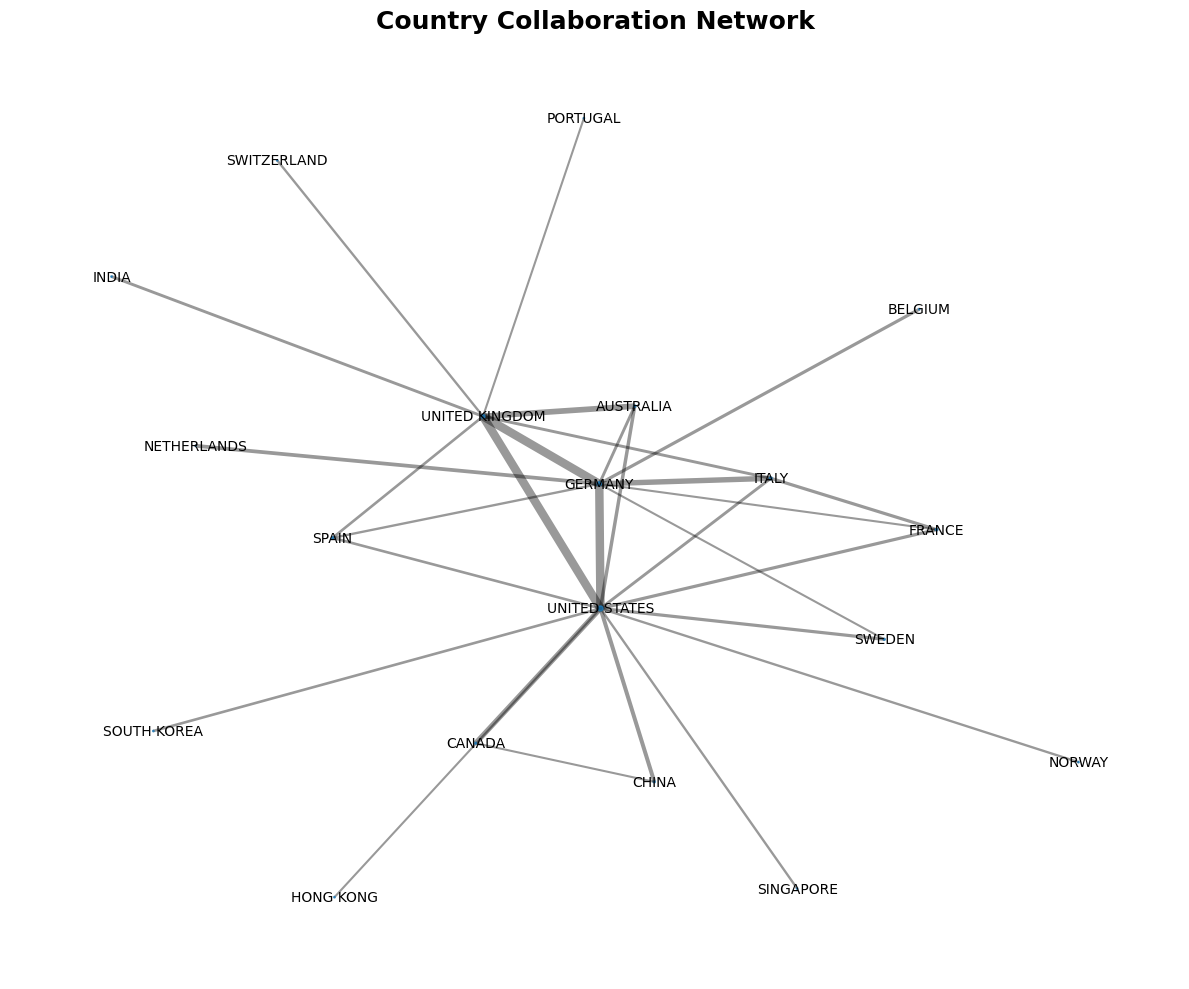

In [27]:
def clean_country(x):
    return str(x).strip().capitalize()

df_main["country_list"] = df_main["affiliation_countries_list"].apply(
    lambda lst: list(set([clean_country(i) for i in lst]))
)

country_pairs = []

for countries in df_main["country_list"]:
    if len(countries) >= 2:
        country_pairs.extend(itertools.combinations(sorted(countries), 2))

pair_counts = Counter(country_pairs)

df_country_edges = pd.DataFrame(
    [(a, b, w) for (a, b), w in pair_counts.items()],
    columns=["country_1", "country_2", "weight"]
)

df_country_edges = df_country_edges.sort_values("weight", ascending=False)

df_country_edges_sub = df_country_edges[df_country_edges["weight"] >= 5]


G_country = nx.Graph()

for _, row in df_country_edges_sub.iterrows():
    G_country.add_edge(
        row["country_1"],
        row["country_2"],
        weight=row["weight"]
    )

plt.figure(figsize=(12, 10))

pos = nx.spring_layout(G_country, k=0.6, seed=42)

# Node size = total collaborations in the full sample.
node_sizes = [G_country.degree(n) for n in G_country.nodes()]

edge_widths = [
    0.5 + G_country[u][v]["weight"] / 5
    for u, v in G_country.edges()
]

labels = {n: n.upper() for n in G_country.nodes()}

nx.draw_networkx_nodes(G_country, pos, node_size=node_sizes, alpha=0.8)
nx.draw_networkx_edges(G_country, pos, width=edge_widths, alpha=0.4)
nx.draw_networkx_labels(G_country, pos, labels, font_size=10)

plt.title("Country Collaboration Network", fontsize=18, fontweight="bold")
plt.axis("off")
plt.tight_layout()
plt.show()
